# TO DO

- structure 
- short introduction
- Explain extended methods of excludeRasterType ("inlcude", "invert", "initialValue" etc)  
- **XXX** Explain alternative methods for exclusions like "exclusion set" - see below
- in 03_extended_methods: use & explain "ec.region.mask.shape", "padExtent", "initialValue", "include"
- "Inclusion Calculator": 
 Generally: ! Create easy basic workflow exmpl using default exlusion. ! 2nd explain that areas can be filter in different ways, or flipped, explain and show etra features like inlude mode in 3rd example
 differentiate: initial Value: the starting mask (100% not/eligible), invert (flip result), exlusion/ inclusion mode. Principally you can work with white or blacklist so to say.
 - include all additional functions from the workshop file (can be found in issue description)
- what does padExtent do 
    * extents the regions boundaries. some of those buffer zones might extend beyond your region boundary. If there’s no padding, those 3 km around the edge would be cut off.
      With padding, you have enough raster around your region to fully calculate those edge effects. Imagine a road lies 1 km outside your regaion boundary but you want an exlusion
      of 3 km around roads => correclty 2 km within your region had to be excluded, what only happens if you consider roads outside your boundaries with padExtent within 1km.  

? Ask srs = LAEA vs 3035 ? [@chris]  
? ec = gl.ExclusionCalculator(
    region=regionPath, 
    **# where="HASC_1='DE.NW'"**,  # what does it do??
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000
    )  
? DEM Mosaic .hgt files ?  
? Prior Datasets ready ? [Tanja]  
? 00_example: clc list from the internet correct?

In the following everything from 00_basic_workflow.ipynb, thats not yet used in 00_basic_workflow_new.ipynb or 01_Placement_algorithm_new.ipynb, is listed

# Introduction

This workbook presents multiple more functions of GLAES:

### Overview:
1) Using exclusion sets
2) Reinitializing previous ExclusionCalculators
3) Drawing with basemaps
4) Accessing grid information
5) Considering region boundary effects with padExtent 
6) excludeRasterType with ranges for clc classes
7) IncludeRasterType
8) Working with Digital Elevation Maps DEM Mosaics to exclude Raster



In [72]:
# Import GLAES
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

clc_path = gl._test_data_["clc-aachen_clipped.tif"]

# Function to initialize new ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# 1. Define all exclusions in an "Exclusion Set"

In [2]:
import pandas as pd

# exclusion_set = pd.read_csv("sample_exclusion_set.csv")
exclusion_set = pd.read_csv(gl._test_data_["sample_exclusion_set.csv"])
exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,type='motorway' OR type='primary' OR type='trunk',200.0


Excluding Raster clc with value [12-22], buffer None, mode exclude, and invert False
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 253.015625 MB


Excluding Raster clc with value [1-2], buffer 1000.0, mode exclude, and invert False


Memory useage during calc: 253.01953125 MB


Excluding Vector osm_roads with where-statement "type='motorway' OR type='primary' OR type='trunk'", buffer 200.0, mode exclude, and invert False 
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 254.04296875 MB


Done!


<Axes: >

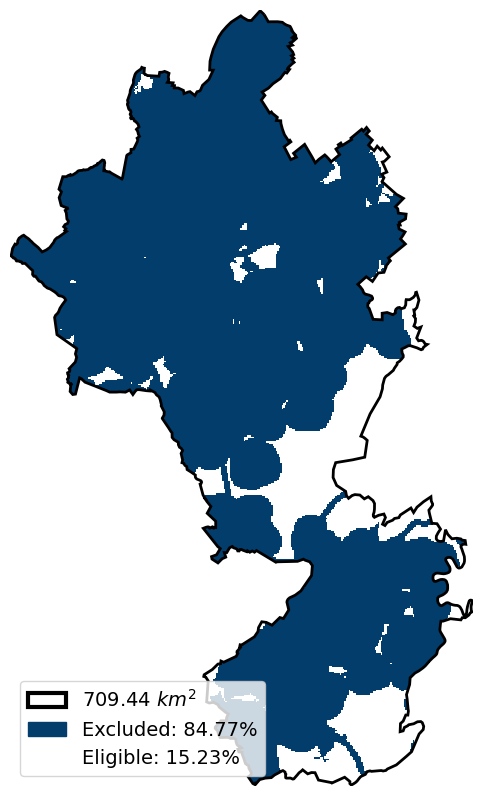

In [14]:
## Make a new ExclusoinCalculator
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

## Apply exclusions from the given set
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=gl._test_data_["clc-aachen_clipped.tif"],
    osm_roads=gl._test_data_["aachenRoads.shp"],
)

## Draw result
ec.draw()

# 2. Reinitialize an ExclusionCalculator from a pre-computed result

This is particularly useful if the original calculation took a while

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 225.4453125 MB


<Axes: >

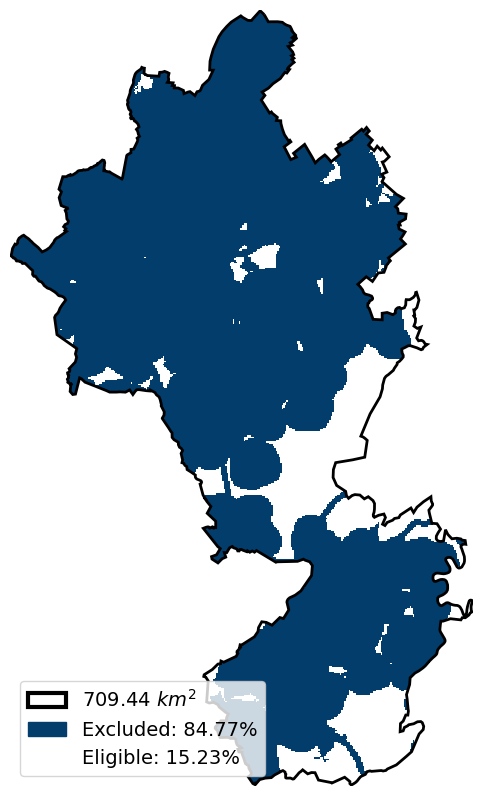

In [7]:
## Set the initial value to those we computer previously
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100, initialValue="tmp/aachens_best_pv_spots.tif")


## Draw the result
ec.draw()

# 3. Draw exclusions with a basemap

Be careful to not use a too-high zoom level!

Also don't forget about using the right attribution

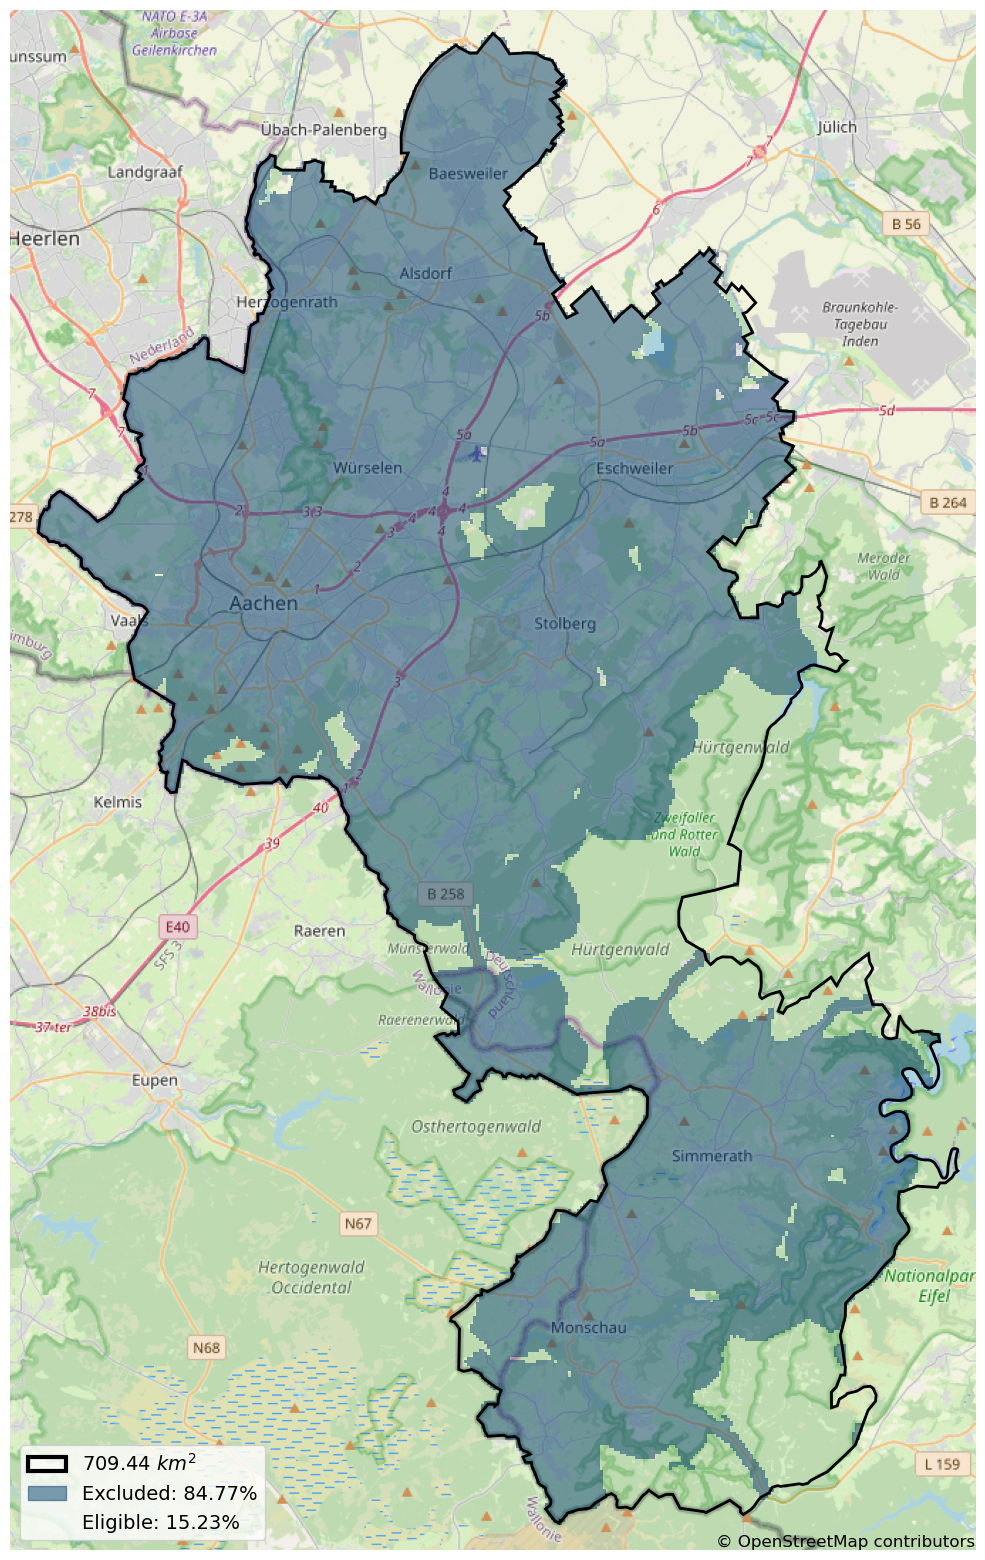

In [15]:
ax = ec.drawWithSmopyBasemap(zoom=11, figsize=(40, 20))

# 4. Access grid information of EC

In [ ]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# Bounding box: smallest rectangle around the region (units: meter, refering to srs)
ec.region.extent
# Mask: Pixel grid inside bounding box, according to pixelRes (True = inside regiion, False = outside region)
ec.region.mask
# Get shape of the mask (rows, columns)
ec.region.mask.shape



xMin: 4037300.000000
xMax: 4067700.000000
yMin: 3049300.000000
yMax: 3100200.000000
srs: PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]

# 5. Considering region boundary effects with padExtent 

In [ ]:
# padExtent increases the bounding box to consider edge effects. 
# For instance, if a road lies just outside your region boundary but you want to exclude a buffer zone
# around it that would reach into your region. Note the chaning coordinates in ec.region.extent and 
# grid size in ec.region.mask.shape when using padExtent:

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=0
    )

print(ec.region.extent)
print(ec.region.mask.shape)

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=2000
    )

print(ec.region.extent)
print(ec.region.mask.shape)

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 121.69921875 MB
(4037300.00000,3049300.00000,4067700.00000,3100200.00000)
(509, 304)
(4035300.00000,3047300.00000,4069700.00000,3102200.00000)
(549, 344)


# 6. excludeRasterType with ranges for clc classes

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 114.3203125 MB


<Axes: >

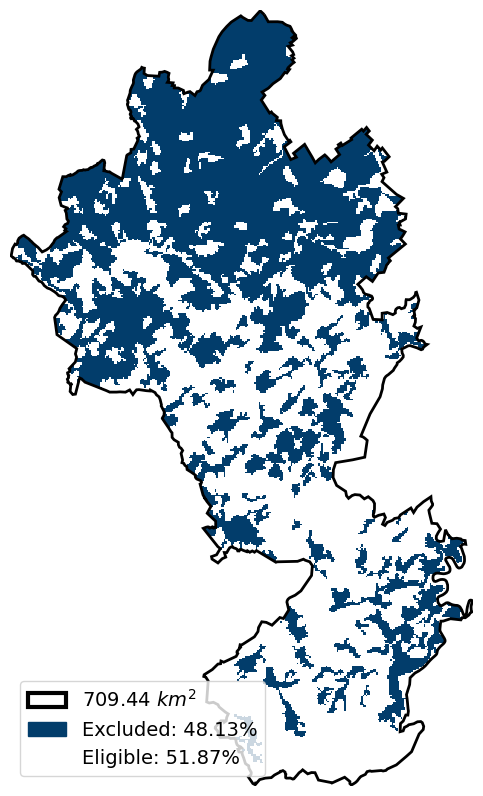

In [ ]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]") # syntax for using ranges
ec.draw()

# 7. Alternative filter methods

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 254.3046875 MB


<Axes: >

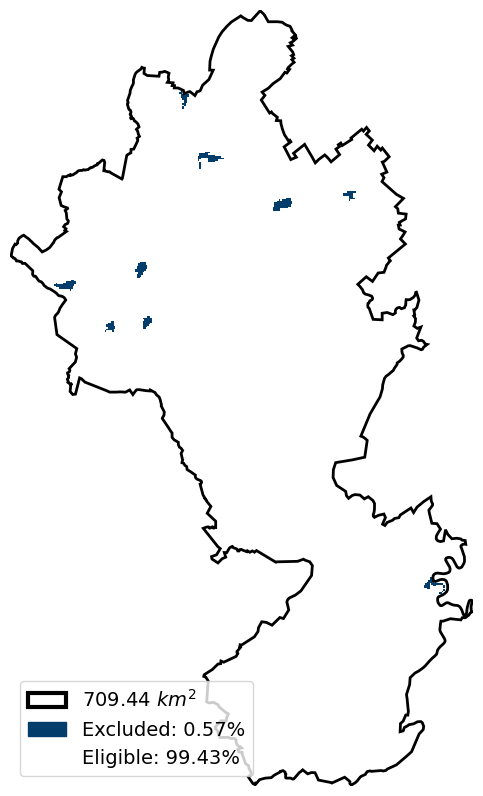

In [ ]:
# use include mode to start with full exclusion and only include the specified clc classes to be eligible

ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include")

ec.draw()

Memory useage during calc: 269.69921875 MB


0.565234551195309

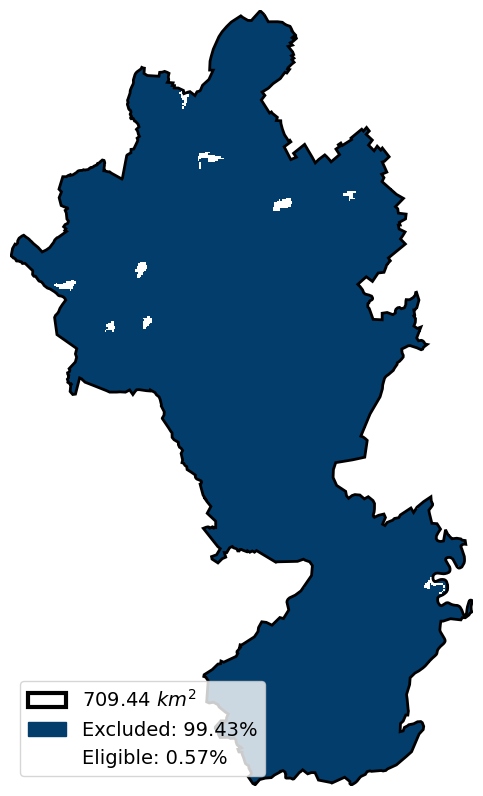

In [67]:
# invert excludeRasterType
ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include", invert=False)

ec.draw()
ec.percentAvailable

In [ ]:

ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]", invert=True)

ec.draw()

# 8. Working with DEM Mosaics to exclude Raster

<class 'osgeo.gdal.Dataset'>


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x0000014947BE3B50>, cbar=<matplotlib.colorbar.Colorbar object at 0x0000014947BF6680>)

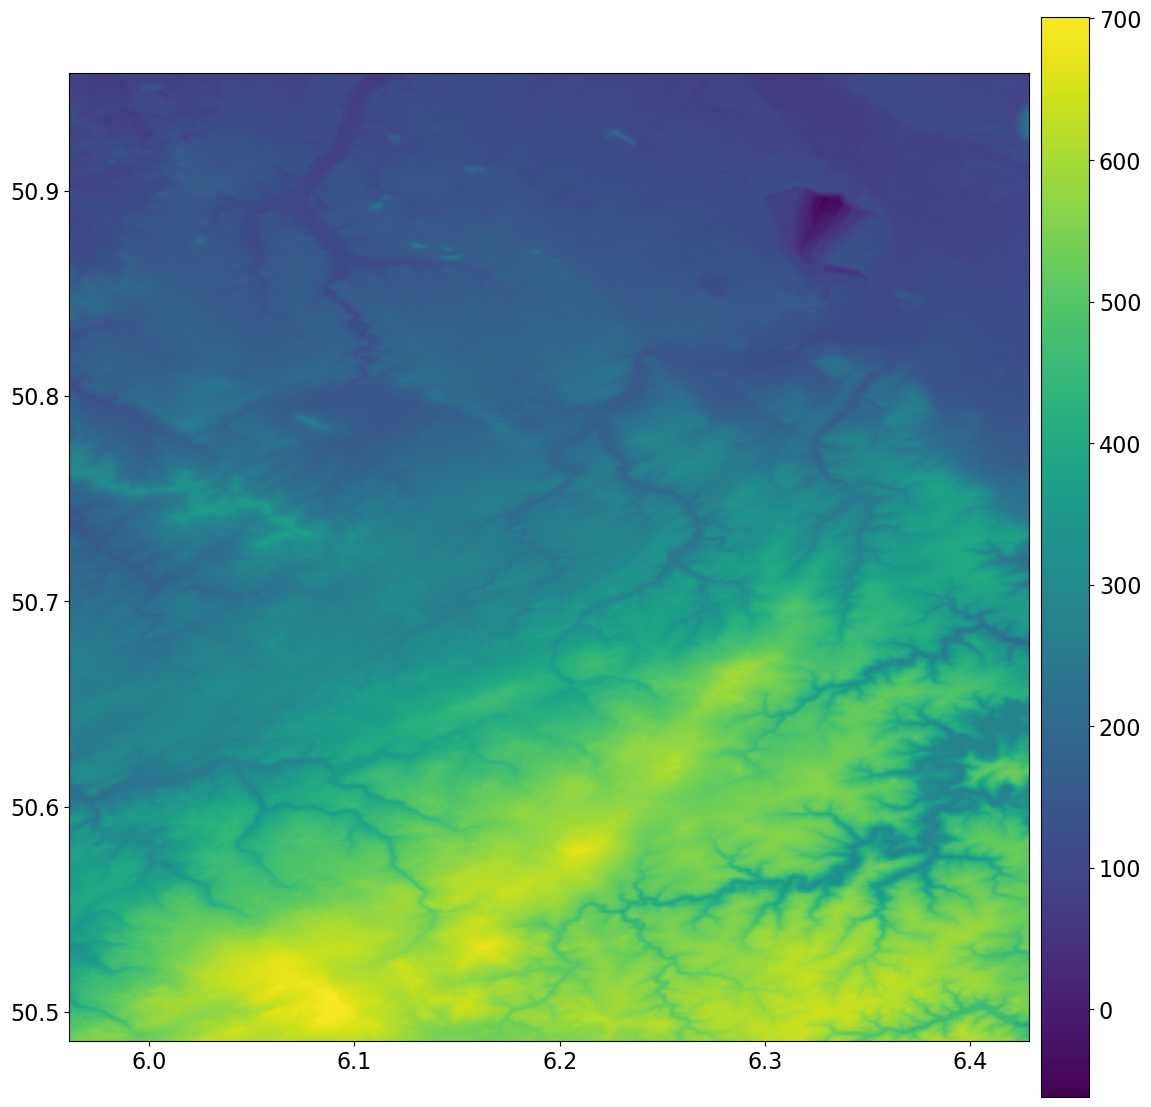

In [ ]:
# Create an elevation mosaic heatmap from digital elevation model (DEM) files. DEMs are raster 
# grids where each pixel stores the ground elevation, forming a digital model of the terrain’s 
# height. Data can be found and downloaded for other regions from https://dwtkns.com/srtm30m . 
# Note, that multiple files might be necessary if your region is large or spans multiple tiles. 
# All files put into .rasterMosaic() will be merged to a single raster mosaic covering the entire region. 

import geokit as gk

dem_raster = ec.region.extent.rasterMosaic(r"C:\Users\j.mutke\Desktop\GLAES_Github\glaes\glaes\test\data\*.hgt")
print(type(dem_raster)) # multiple DEM files merged into a single raster mosaic
gk.drawRaster(dem_raster)


c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 139.7109375 MB


<Axes: >

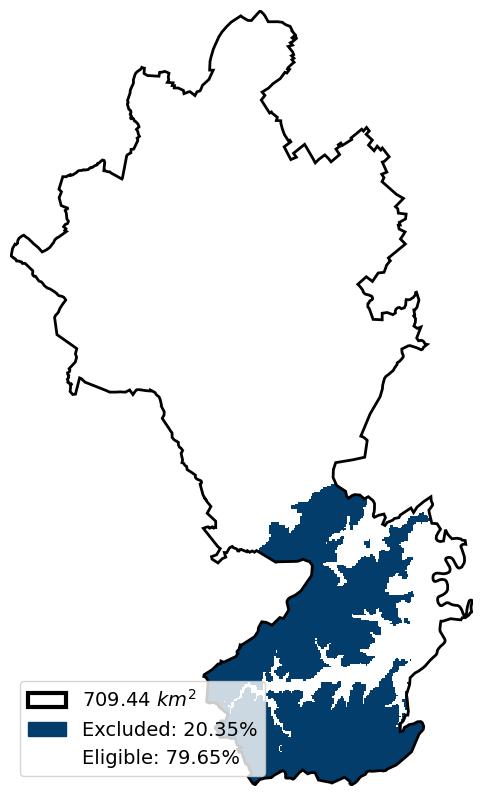

In [ ]:
# exclude areas above 500m elevation. Note, that here the hilly Eiffel region is mainly exluded in the region's south.
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 202.3984375 MB


<Axes: >

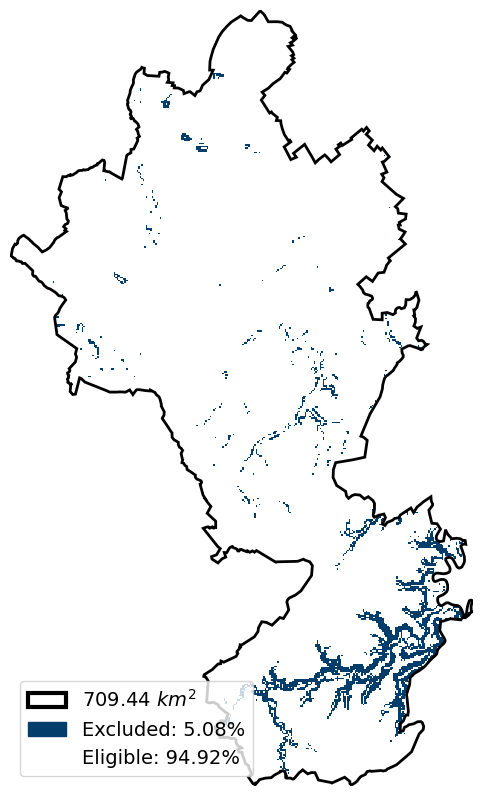

In [ ]:
# Exclude Raster - DEM Gradient Mosaic. Exlude slopes above 15 degrees.

dem_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(                          # computes the gradient (slope) of a raster
            source=dem_raster,
            factor="latlonToM"),                        # factor to convert lat/lon degrees to meters
    processor=lambda x: np.degrees(np.arctan(x))        # convert gradient to degrees
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_gradiate_raster, value=(15, None), resampleAlg="mode")

ec.draw()

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 253.125 MB
<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x000001494E613990> >


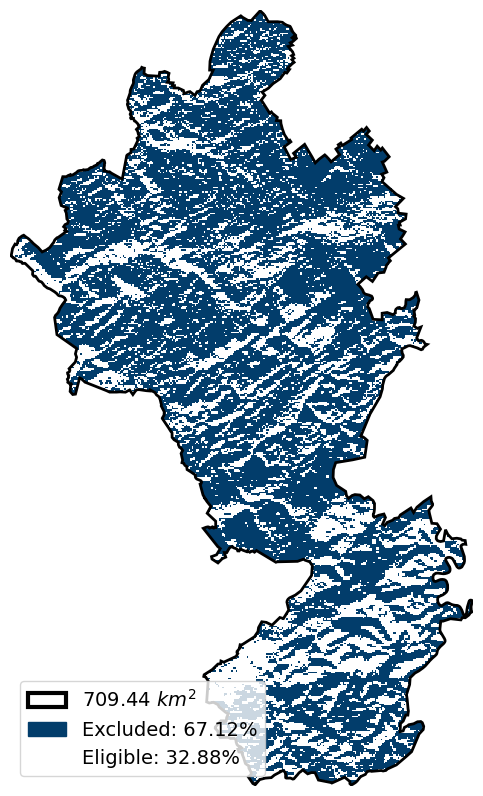

In [ ]:
# Exlude slopes with north orientation, as north facing slopes receive less radiation.

dem_ns_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# exclude all north facing slopes (values > 0 degrees)
ec.excludeRasterType(dem_ns_gradiate_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# 9. ExcludeVectorType

# 10 Visualization Methods (Smopy)

# Miscellaneous

In [ ]:
# Exclude Raster - resolutionDiv
# Exclude Raster - prewarp
# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

0.565234551195309